<a href="https://colab.research.google.com/github/matjekolenka-phd/workshop_python_/blob/main/Day_2_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# PART 1: INSTALL AND IMPORT
# ==============================

!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================
# PART 2A: LOAD DATA
# ==============================

# Upload CSV file
uploaded = files.upload()

# Read the uploaded file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Clean column names
df.columns = df.columns.str.strip()

# Display first rows
print("First 5 rows:")
display(df.head())

# Show number of rows and columns
print("\nDataset shape:")
print(df.shape)

# Show column names
print("\nColumn names:")
print(df.columns)

Saving Mortality_ration.csv to Mortality_ration.csv
First 5 rows:


,Entity,Year,Maternal mortality ratio,Classification
0,Afghanistan,1985,2231.5060,Extremely high
1,Afghanistan,1986,1856.9208,Extremely high
2,Afghanistan,1987,1820.5913,Extremely high
3,Afghanistan,1988,1571.6926,Extremely high
4,Afghanistan,1989,1520.0275,Extremely high



Dataset shape:
(10306, 4)

Column names:
Index(['Entity', 'Year', 'Maternal mortality ratio', 'Classification'], dtype='object')


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10306 entries, 0 to 10305
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    10306 non-null  object 
 1   Year                      10306 non-null  int64  
 2   Maternal mortality ratio  10229 non-null  float64
 3   Classification            10306 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 322.2+ KB

Missing values:
Entity                       0
Year                         0
Maternal mortality ratio    77
Classification               0
dtype: int64

Summary statistics:


,Entity,Year,Maternal mortality ratio,Classification
count,10306,10306.000000,10229.000000,10306
unique,283,NaN,NaN,5
top,Sweden,NaN,NaN,Low
freq,272,NaN,NaN,5662
mean,NaN,1989.440229,246.453008,NaN
std,NaN,39.083091,391.483222,NaN
min,NaN,1751.000000,0.107251,NaN
25%,NaN,1987.000000,21.607850,NaN
50%,NaN,1999.000000,80.210976,NaN
75%,NaN,2011.000000,352.641330,NaN



Class variable selected:
Classification

Classification categories:
['Extremely high' 'Very high' 'High' 'Low' 'Moderate']

Class distribution:
Classification
Low               5662
Moderate          1808
Very high         1330
High              1060
Extremely high     446
Name: count, dtype: int64


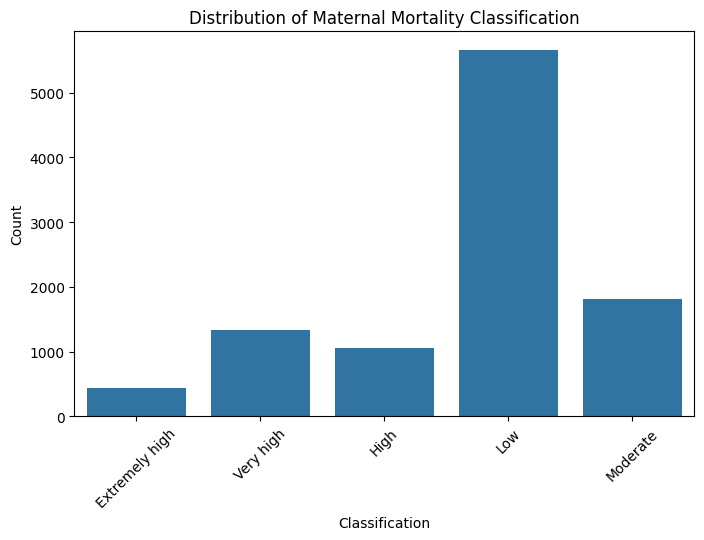

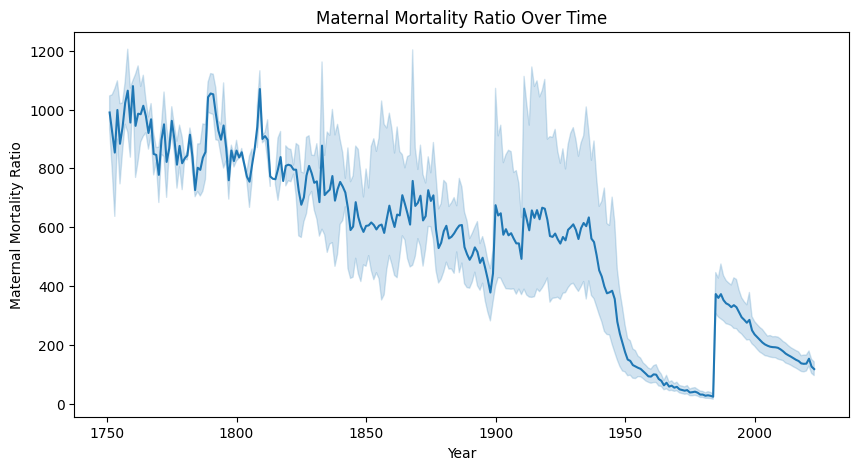

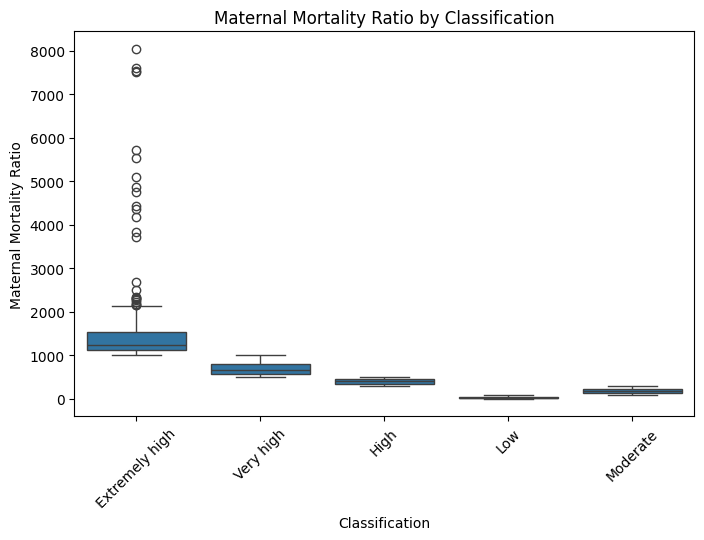

In [ ]:
# ==============================
# PART 2B: EXPLORE DATA
# ==============================

# Show dataset information
print("Dataset information:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Convert Year and Maternal mortality ratio to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Maternal mortality ratio"] = pd.to_numeric(df["Maternal mortality ratio"], errors="coerce")

# Summary statistics
print("\nSummary statistics:")
display(df.describe(include="all"))

# Specify the class variable
class_variable = "Classification"

print("\nClass variable selected:")
print(class_variable)

# Show classification categories
print("\nClassification categories:")
print(df[class_variable].unique())

# Show class distribution
print("\nClass distribution:")
print(df[class_variable].value_counts())

# Plot class distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x=class_variable)
plt.title("Distribution of Maternal Mortality Classification")
plt.xlabel("Classification")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Plot maternal mortality ratio over time
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Year", y="Maternal mortality ratio")
plt.title("Maternal Mortality Ratio Over Time")
plt.xlabel("Year")
plt.ylabel("Maternal Mortality Ratio")
plt.show()

# Plot maternal mortality ratio by classification
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x=class_variable, y="Maternal mortality ratio")
plt.title("Maternal Mortality Ratio by Classification")
plt.xlabel("Classification")
plt.ylabel("Maternal Mortality Ratio")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================
# PART 2C: TRAIN THE KNN MODEL
# ==============================

# Remove rows where the class variable is missing
df_model = df.dropna(subset=[class_variable])

# Because KNN uses numeric distance, we must handle missing values carefully.
# Since Maternal mortality ratio has some missing values, remove those rows for this model.
df_model = df_model.dropna(subset=["Maternal mortality ratio", "Year"])

# Choose whether to use Maternal mortality ratio as a predictor
# True = use MMR to predict Classification
# False = use only Entity and Year
use_mmr_as_feature = True

if use_mmr_as_feature:
    X = df_model.drop(columns=[class_variable])
else:
    X = df_model.drop(columns=[class_variable, "Maternal mortality ratio"])

y = df_model[class_variable]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

# Preprocess numeric data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocess categorical data
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build KNN model
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Train model
knn_model.fit(X_train, y_train)

print("KNN model training completed successfully.")

Numeric features:
['Year', 'Maternal mortality ratio']

Categorical features:
['Entity']
KNN model training completed successfully.


MODEL PERFORMANCE
------------------
Accuracy: 0.956
Precision: 0.955
Recall: 0.956
F1-score: 0.955

Detailed classification report:
                precision    recall  f1-score   support

Extremely high       0.95      0.93      0.94        89
          High       0.87      0.88      0.88       212
           Low       0.98      0.99      0.99      1117
      Moderate       0.95      0.91      0.93       362
     Very high       0.93      0.92      0.92       266

      accuracy                           0.96      2046
     macro avg       0.94      0.93      0.93      2046
  weighted avg       0.96      0.96      0.96      2046



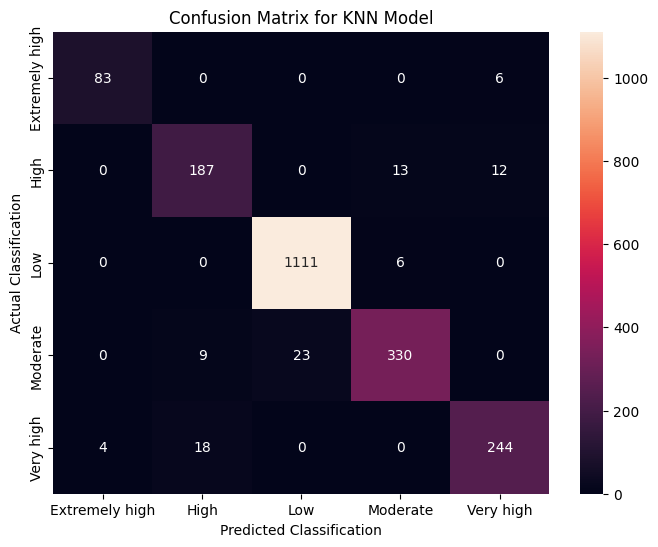

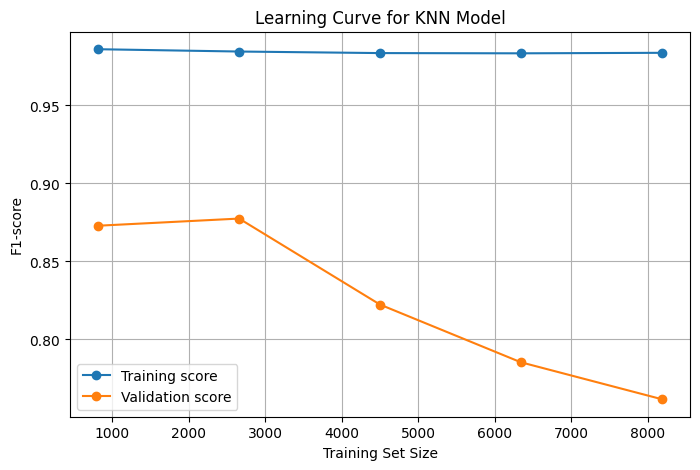

In [ ]:
# ==============================
# PART 3: RUN MODEL AND EVALUATE PERFORMANCE
# ==============================

# Make predictions
y_pred = knn_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("MODEL PERFORMANCE")
print("------------------")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=knn_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)
plt.xlabel("Predicted Classification")
plt.ylabel("Actual Classification")
plt.title("Confusion Matrix for KNN Model")
plt.show()

# Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    knn_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean, marker="o", label="Training score")
plt.plot(train_sizes, test_scores_mean, marker="o", label="Validation score")
plt.xlabel("Training Set Size")
plt.ylabel("F1-score")
plt.title("Learning Curve for KNN Model")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==============================
# PART 2C: FEATURE SELECTION TABLE
# ==============================

# Remove rows where the class variable is missing
df_model = df.dropna(subset=[class_variable])

# Remove rows where Year or Maternal mortality ratio is missing
df_model = df_model.dropna(subset=["Year", "Maternal mortality ratio"])

# Choose whether to use Maternal mortality ratio as a feature
# True = include Maternal mortality ratio in the model
# False = exclude it
use_mmr_as_feature = True

# Create feature selection table
feature_selection_table = pd.DataFrame({
    "Variable": ["Entity", "Year", "Maternal mortality ratio", "Classification"],
    "Type": ["Categorical", "Numeric", "Numeric", "Categorical"],
    "Role": [
        "Predictor variable",
        "Predictor variable",
        "Predictor variable" if use_mmr_as_feature else "Excluded variable",
        "Class variable / Target variable"
    ],
    "Included in model": [
        "Yes",
        "Yes",
        "Yes" if use_mmr_as_feature else "No",
        "No"
    ],
    "Reason": [
        "Shows the country or region",
        "Shows the year of observation",
        "Shows the maternal mortality ratio used to classify mortality level",
        "This is the outcome the model is trying to predict"
    ]
})

print("Feature Selection Table:")
display(feature_selection_table)

Feature Selection Table:


,Variable,Type,Role,Included in model,Reason
0,Entity,Categorical,Predictor variable,Yes,Shows the country or region
1,Year,Numeric,Predictor variable,Yes,Shows the year of observation
2,Maternal mortality ratio,Numeric,Predictor variable,Yes,Shows the maternal mortality ratio used to cla...
3,Classification,Categorical,Class variable / Target variable,No,This is the outcome the model is trying to pre...


In [ ]:
# ==============================
# PART 2D: TRAIN THE KNN MODEL
# ==============================

# Define predictor variables X and target variable y
if use_mmr_as_feature:
    X = df_model[["Entity", "Year", "Maternal mortality ratio"]]
else:
    X = df_model[["Entity", "Year"]]

y = df_model[class_variable]

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

# Preprocess numeric data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocess categorical data
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build KNN model
# K = 5
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Train model
knn_model.fit(X_train, y_train)

print("KNN model training completed successfully.")

Numeric features:
['Year', 'Maternal mortality ratio']

Categorical features:
['Entity']
KNN model training completed successfully.


Detailed classification report:
                precision    recall  f1-score   support

Extremely high       0.95      0.93      0.94        89
          High       0.87      0.88      0.88       212
           Low       0.98      0.99      0.99      1117
      Moderate       0.95      0.91      0.93       362
     Very high       0.93      0.92      0.92       266

      accuracy                           0.96      2046
     macro avg       0.94      0.93      0.93      2046
  weighted avg       0.96      0.96      0.96      2046



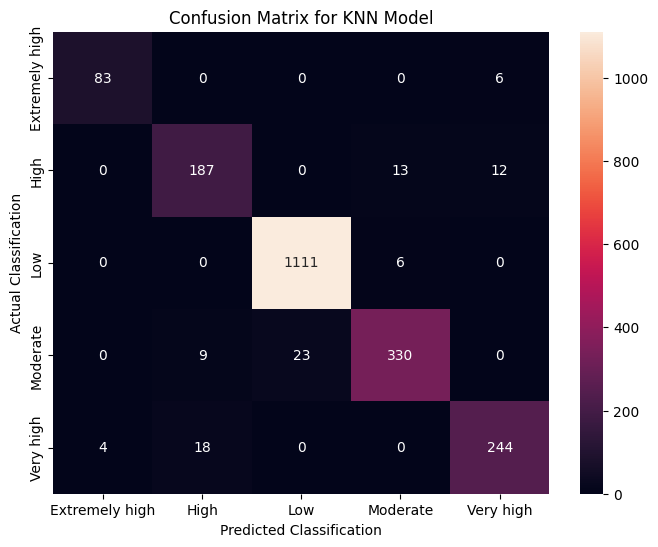

In [ ]:
# ==============================
# PART 3B: CLASSIFICATION REPORT AND CONFUSION MATRIX
# ==============================

# Detailed classification report
print("Detailed classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=knn_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.xlabel("Predicted Classification")
plt.ylabel("Actual Classification")
plt.title("Confusion Matrix for KNN Model")
plt.show()

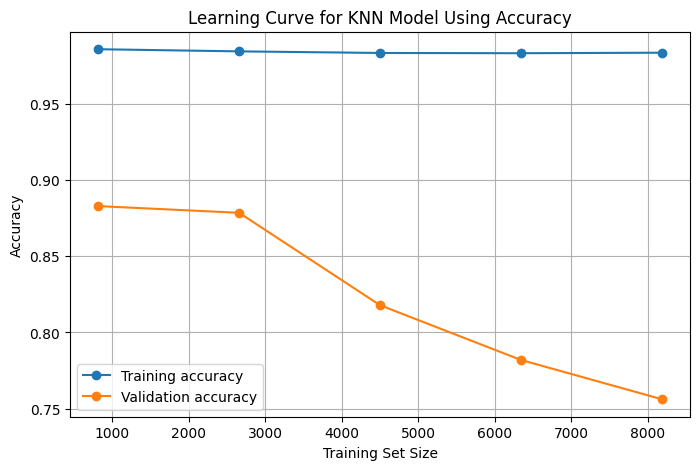

In [ ]:
# ==============================
# PART 3C: LEARNING CURVE USING ACCURACY
# ==============================

# Create learning curve using accuracy
train_sizes, train_scores, test_scores = learning_curve(
    knn_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Calculate mean training and validation accuracy
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curve against accuracy
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean, marker="o", label="Training accuracy")
plt.plot(train_sizes, test_scores_mean, marker="o", label="Validation accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for KNN Model Using Accuracy")
plt.legend()
plt.grid(True)
plt.show()